In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
df= pd.read_excel("Sales_Data_200_Rows.xlsx")
df



,Order ID,Date,Customer,City,Region,Category,Product,Quantity,Unit Price,Cost Price,Sales,Profit
0,1001,01-01-2025,Sara,Islamabad,ICT,Furniture,Chair,6,7000,5500,42000,Profit
1,1002,02-01-2025,Ayesha,Islamabad,ICT,Furniture,Table,4,15000,12000,60000,Profit
2,1003,03-01-2025,Sara,Lahore,Punjab,Electronics,Monitor,5,35000,30000,175000,Profit
3,1004,04-01-2025,Ahmed,Karachi,Sindh,Electronics,Monitor,7,35000,30000,245000,Profit
4,1005,05-01-2025,Sara,Quetta,Balochistan,Electronics,Laptop,7,80000,70000,560000,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...
195,1196,15-07-2025,Zain,Islamabad,ICT,Accessories,Keyboard,5,3000,2200,15000,Profit
196,1197,16-07-2025,Ahmed,Peshawar,KPK,Electronics,Laptop,3,80000,70000,240000,Profit
197,1198,17-07-2025,Hina,Lahore,Punjab,Electronics,Printer,2,25000,21000,50000,Profit
198,1199,18-07-2025,Fatima,Karachi,Sindh,Accessories,Keyboard,8,3000,2200,24000,Profit


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Order ID    200 non-null    int64
 1   Date        200 non-null    str  
 2   Customer    200 non-null    str  
 3   City        200 non-null    str  
 4   Region      200 non-null    str  
 5   Category    200 non-null    str  
 6   Product     200 non-null    str  
 7   Quantity    200 non-null    int64
 8   Unit Price  200 non-null    int64
 9   Cost Price  200 non-null    int64
 10  Sales       200 non-null    int64
 11  Profit      200 non-null    str  
dtypes: int64(5), str(7)
memory usage: 28.8 KB


Order ID      0
Date          0
Customer      0
City          0
Region        0
Category      0
Product       0
Quantity      0
Unit Price    0
Cost Price    0
Sales         0
Profit        0
dtype: int64

In [6]:
df.describe()

,Order ID,Quantity,Unit Price,Cost Price,Sales
count,200.000000,200.000000,200.000000,200.000000,200.00000
mean,1100.500000,4.530000,20347.500000,17243.000000,93040.00000
std,57.879185,2.266004,23661.940557,20804.801123,136725.43701
min,1001.000000,1.000000,1500.000000,1100.000000,1500.00000
25%,1050.750000,3.000000,3000.000000,2200.000000,12000.00000
50%,1100.500000,4.000000,15000.000000,12000.000000,42000.00000
75%,1150.250000,6.000000,25000.000000,21000.000000,105000.00000
max,1200.000000,8.000000,80000.000000,70000.000000,640000.00000


In [11]:
df['Sales'].sum()
df['Cost Price'].sum()

np.int64(3448600)

In [15]:
df['Profit']=df['Sales']-(df['Cost Price']*df['Quantity'])
df['Profit'].sum()
df.columns

Index(['Order ID', 'Date', 'Customer', 'City', 'Region', 'Category', 'Product',
       'Quantity', 'Unit Price', 'Cost Price', 'Sales', 'Profit'],
      dtype='str')

In [16]:
df.groupby("Category")["Sales"].sum()

Category
Accessories      702000
Electronics    15200000
Furniture       2706000
Name: Sales, dtype: int64

In [17]:
df.groupby('Region')["Sales"].sum()

Region
Balochistan    2241500
ICT            1395500
KPK            2307000
Punjab         9623500
Sindh          3040500
Name: Sales, dtype: int64

In [18]:
df.groupby('Region')["Profit"].sum()

Region
Balochistan     360600
ICT             232900
KPK             358600
Punjab         1429700
Sindh           444400
Name: Profit, dtype: int64

In [19]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Laptop      8400000
Printer     3650000
Monitor     3150000
Table       1740000
Chair        966000
Keyboard     471000
Mouse        231000
Name: Sales, dtype: int64

In [3]:
sales = df.groupby('Product')['Sales'].sum()
print(sales)

Product
Chair        966000
Keyboard     471000
Laptop      8400000
Monitor     3150000
Mouse        231000
Printer     3650000
Table       1740000
Name: Sales, dtype: int64


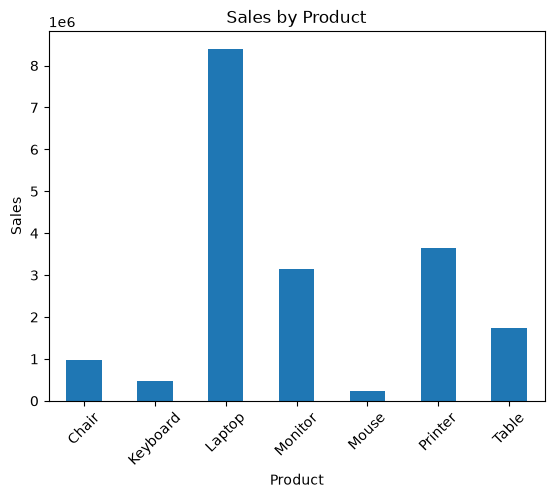

In [4]:
import matplotlib.pyplot as plt

sales.plot(kind='bar')

plt.title('Sales by Product')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [7]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

average_sales = df['Sales'].mean()
print("Average Sales:", average_sales)

highest_sale = df['Sales'].max()
print("Highest Sale:", highest_sale)

lowest_sale = df['Sales'].min()
print("Lowest Sale:", lowest_sale)

Total Sales: 18608000
Average Sales: 93040.0
Highest Sale: 640000
Lowest Sale: 1500


Region
Balochistan    2241500
ICT            1395500
KPK            2307000
Punjab         9623500
Sindh          3040500
Name: Sales, dtype: int64


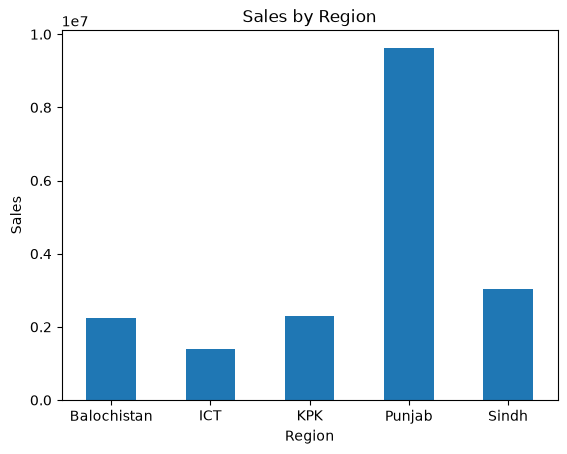

In [8]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

In [10]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()

print(monthly_sales)

Date
2025-01    2691000
2025-02    4375500
2025-03    3287500
2025-04    2484000
2025-05    2572000
2025-06    2090500
2025-07    1107500
Freq: M, Name: Sales, dtype: int64


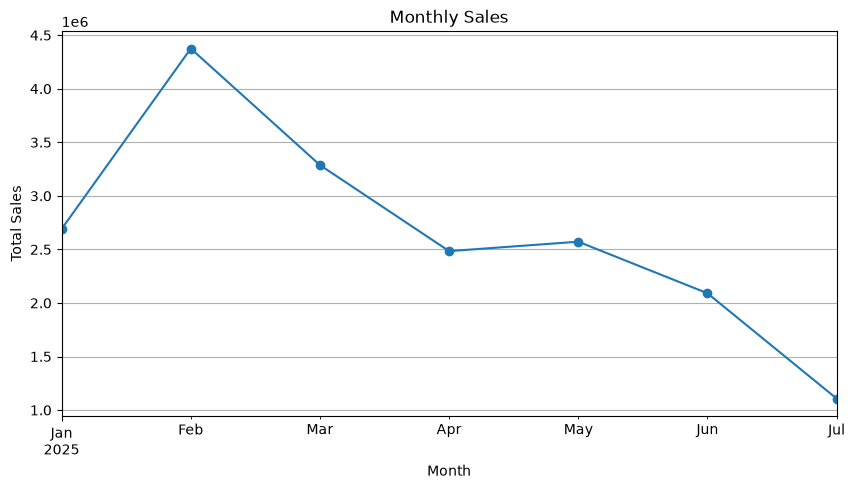

In [11]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

In [12]:
best_month = monthly_sales.idxmax()
best_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_sales = monthly_sales.min()

print("Best Sales Month:", best_month)
print("Best Sales:", best_sales)

print("Worst Sales Month:", worst_month)
print("Worst Sales:", worst_sales)

Best Sales Month: 2025-02
Best Sales: 4375500
Worst Sales Month: 2025-07
Worst Sales: 1107500


In [ ]:
daily_sales = df.groupby('Date')['Sales'].sum()

print(daily_sales)


Date
2025-01-01     42000
2025-01-02     60000
2025-01-03    175000
2025-01-04    245000
2025-01-05    560000
               ...  
2025-07-15     15000
2025-07-16    240000
2025-07-17     50000
2025-07-18     24000
2025-07-19     25000
Name: Sales, Length: 200, dtype: int64


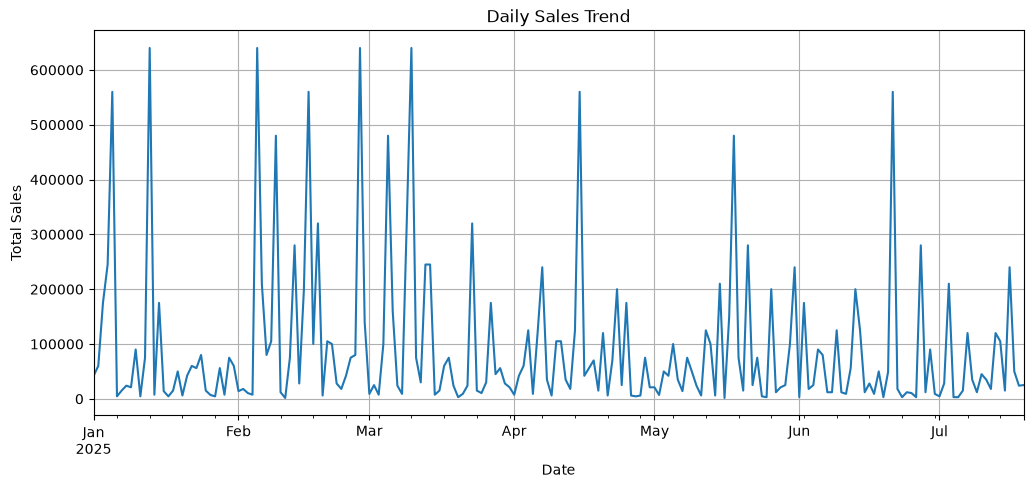

In [14]:
daily_sales.plot(kind='line', figsize=(12,5))

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

Product
Laptop     8400000
Printer    3650000
Monitor    3150000
Table      1740000
Chair       966000
Name: Sales, dtype: int64


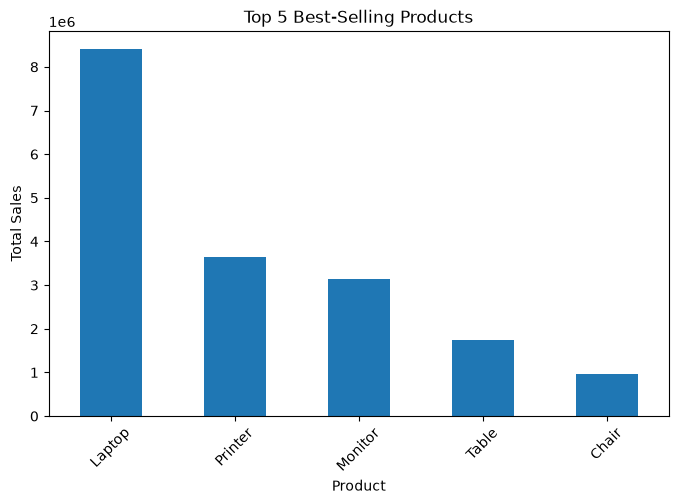

In [15]:
top_5_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)

print(top_5_products)

top_5_products.plot(kind='bar', figsize=(8,5))

plt.title('Top 5 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

Category
Electronics    81.69
Furniture      14.54
Accessories     3.77
Name: Sales, dtype: float64


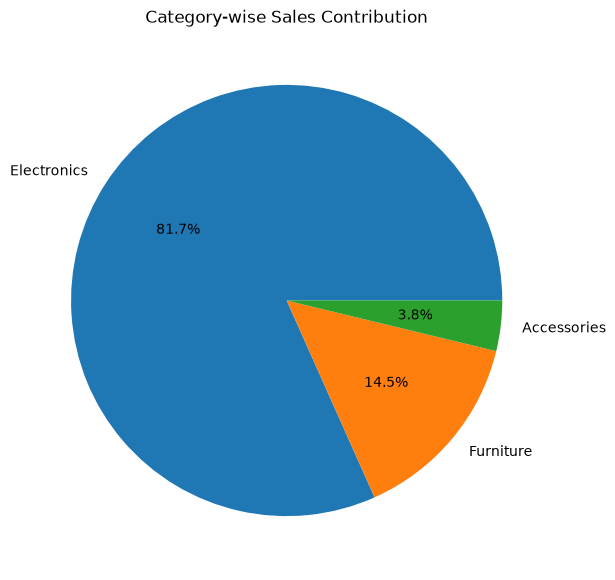

In [17]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales_percentage = (category_sales / category_sales.sum()) * 100

print(category_sales_percentage.round(2))

category_sales_percentage.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Category-wise Sales Contribution')
plt.ylabel('')

plt.show()

          Quantity    Sales
Product                    
Laptop         105  8400000
Printer        146  3650000
Monitor         90  3150000
Table          116  1740000
Chair          138   966000
Keyboard       157   471000
Mouse          154   231000


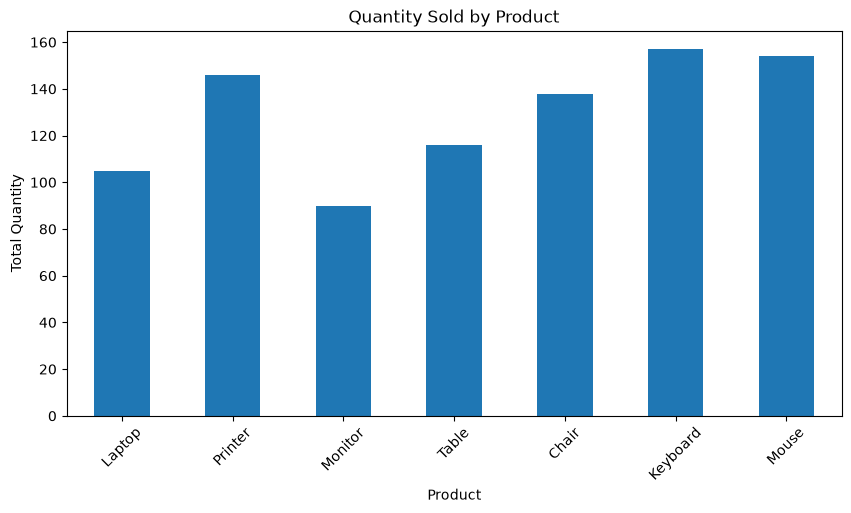

In [18]:
quantity_sales = df.groupby('Product').agg({
    'Quantity': 'sum',
    'Sales': 'sum'
}).sort_values('Sales', ascending=False)

print(quantity_sales)

quantity_sales['Quantity'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)

plt.show()

Correlation between Quantity and Sales: 0.4


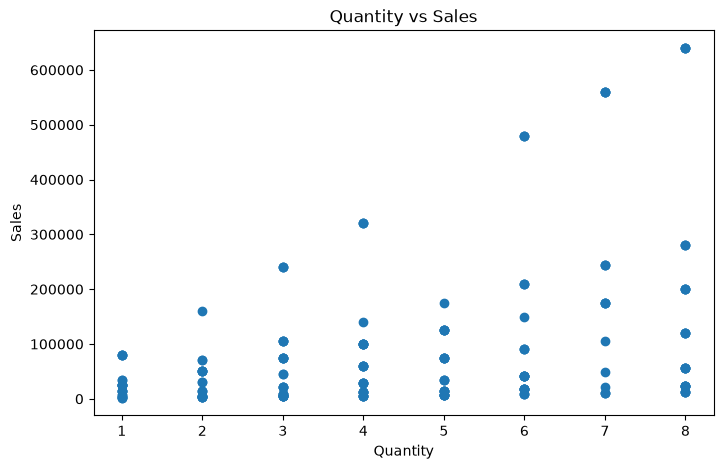

In [20]:
correlation = df['Quantity'].corr(df['Sales'])

print("Correlation between Quantity and Sales:", round(correlation, 2))

plt.figure(figsize=(8,5))

plt.scatter(df['Quantity'], df['Sales'])

plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')

plt.show()